In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.22.0-rc0


In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("Train images:", x_train.shape)
print("Train labels:", y_train.shape)
print("Test images: ", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 7s 1us/step
Train images: (60000, 28, 28)
Train labels: (60000,)
Test images:  (10000, 28, 28)


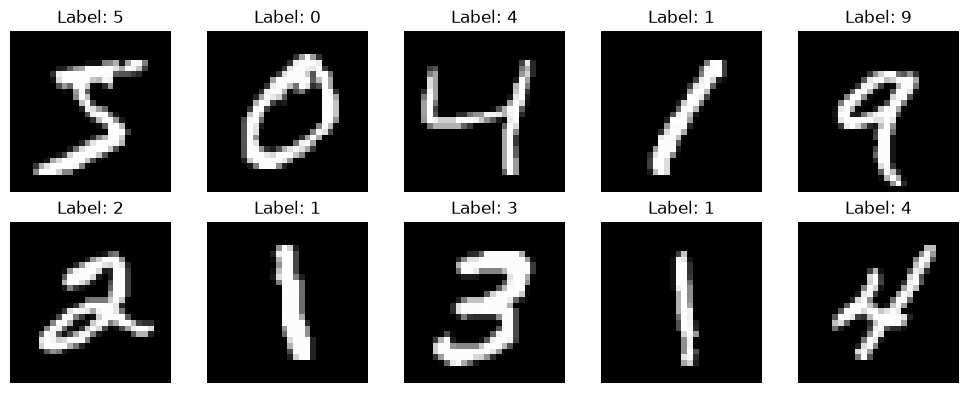

In [3]:
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title("Label: " + str(y_train[i]))
    plt.axis("off")
plt.tight_layout()
plt.show()

In [4]:
print("Smallest pixel value:", x_train.min())
print("Largest pixel value: ", x_train.max())
print("Label of first image:", y_train[0])

Smallest pixel value: 0
Largest pixel value:  255
Label of first image: 5


In [5]:
# 1. Scale pixel values from 0-255 down to 0-1
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# 2. Add a "channel" dimension (1 = grayscale)
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

print("Train shape:", x_train.shape)
print("Pixel range:", x_train.min(), "to", x_train.max())

Train shape: (60000, 28, 28, 1)
Pixel range: 0.0 to 1.0


In [6]:
model = keras.Sequential([
    keras.Input(shape=(28, 28, 1)),

    keras.layers.Conv2D(32, (3, 3), activation="relu"),
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Conv2D(64, (3, 3), activation="relu"),
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Flatten(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(10, activation="softmax"),
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [8]:
history = model.fit(
    x_train, y_train,
    epochs=8,
    batch_size=128,
    validation_split=0.1,
)

Epoch 1/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.9059 - loss: 0.3287 - val_accuracy: 0.9802 - val_loss: 0.0749
Epoch 2/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - accuracy: 0.9713 - loss: 0.0922 - val_accuracy: 0.9862 - val_loss: 0.0550
Epoch 3/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 27s 42ms/step - accuracy: 0.9787 - loss: 0.0686 - val_accuracy: 0.9892 - val_loss: 0.0464
Epoch 4/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 18s 37ms/step - accuracy: 0.9826 - loss: 0.0576 - val_accuracy: 0.9900 - val_loss: 0.0409
Epoch 5/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.9846 - loss: 0.0497 - val_accuracy: 0.9900 - val_loss: 0.0398
Epoch 6/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9861 - loss: 0.0445 - val_accuracy: 0.9910 - val_loss: 0.0346
Epoch 7/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.9875 - loss: 0.0398 - val_accuracy: 0.9898 - val_loss: 0.0374
Epoch 8/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.9888 - loss: 0.0368 - val_accuracy

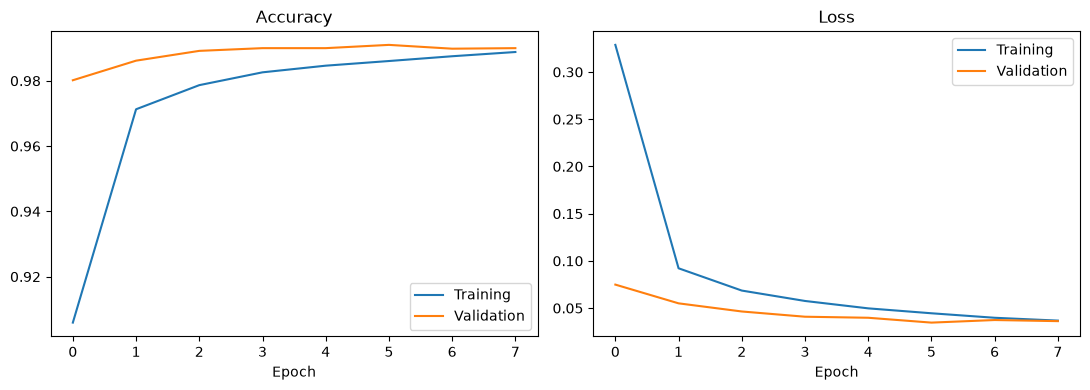

In [9]:
plt.figure(figsize=(11, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training")
plt.plot(history.history["val_loss"], label="Validation")
plt.title("Loss")
plt.xlabel("Epoch")
plt.legend()

plt.tight_layout()
plt.show()

In [10]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print("Test accuracy:", round(test_acc * 100, 2), "%")
print("Test loss:", round(test_loss, 4))

Test accuracy: 98.84 %
Test loss: 0.0311


In [11]:
from sklearn.metrics import classification_report

probs = model.predict(x_test, verbose=0)
y_pred = np.argmax(probs, axis=1)

print(classification_report(y_test, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.980     0.997     0.988       980
           1      0.992     0.996     0.994      1135
           2      0.988     0.984     0.986      1032
           3      0.980     0.997     0.988      1010
           4      0.995     0.987     0.991       982
           5      0.989     0.985     0.987       892
           6      0.994     0.986     0.990       958
           7      0.989     0.986     0.988      1028
           8      0.988     0.987     0.987       974
           9      0.990     0.976     0.983      1009

    accuracy                          0.988     10000
   macro avg      0.988     0.988     0.988     10000
weighted avg      0.988     0.988     0.988     10000



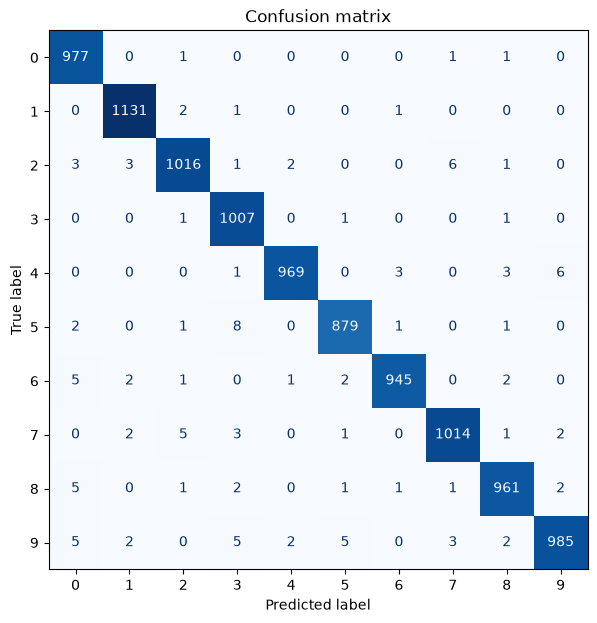

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion matrix")
plt.show()

Number of mistakes: 116


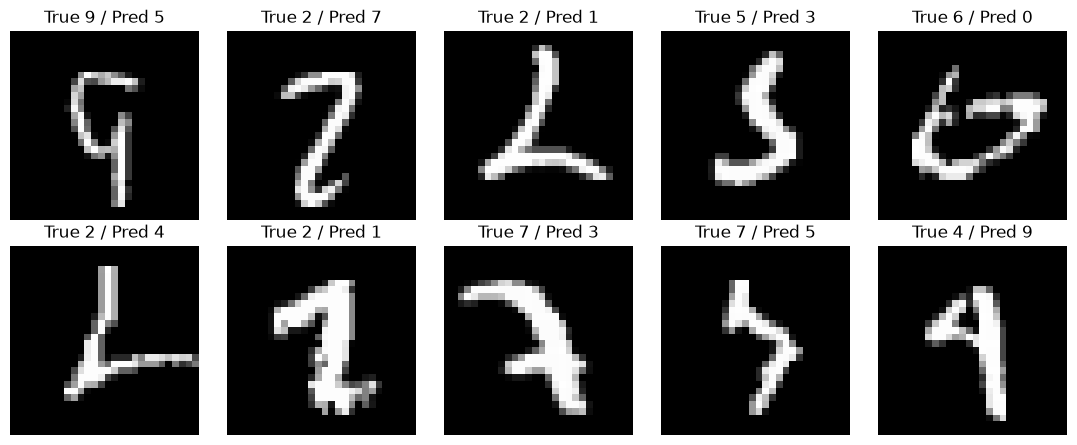

In [13]:
wrong = np.where(y_pred != y_test)[0]
print("Number of mistakes:", len(wrong))

plt.figure(figsize=(11, 4.5))
for i, idx in enumerate(wrong[:10]):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[idx].reshape(28, 28), cmap="gray")
    plt.title(f"True {y_test[idx]} / Pred {y_pred[idx]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [14]:
model.save("digit_cnn.keras")
print("Model saved!")

Model saved!


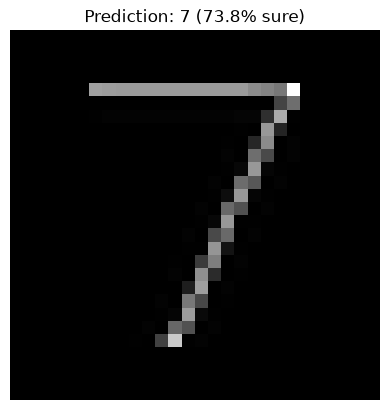

Digit 7: 73.8%
Digit 1: 12.1%
Digit 3: 9.4%


In [18]:
def predict_digit(path):
    img = Image.open(path).convert("L")
    arr = np.array(img).astype("float32")

    # 1. Make it a white digit on a black background
    if arr.mean() > 127:
        arr = 255 - arr

    # 2. Crop tightly around the digit
    ys, xs = np.where(arr > 50)
    arr = arr[ys.min():ys.max() + 1, xs.min():xs.max() + 1]

    # 3. Resize so the longest side is 20 pixels (keeps the shape)
    h, w = arr.shape
    scale = 20 / max(h, w)
    new_h, new_w = max(1, round(h * scale)), max(1, round(w * scale))
    small = Image.fromarray(arr.astype("uint8")).resize((new_w, new_h), Image.LANCZOS)

    # 4. Place it in the center of a 28x28 black canvas
    canvas = np.zeros((28, 28), dtype="float32")
    top, left = (28 - new_h) // 2, (28 - new_w) // 2
    canvas[top:top + new_h, left:left + new_w] = np.array(small)

    # 5. Scale to 0-1 and make the brightest pixel exactly 1.0
    canvas = canvas / canvas.max()

    probs = model.predict(canvas.reshape(1, 28, 28, 1), verbose=0)[0]
    top3 = np.argsort(probs)[::-1][:3]

    plt.imshow(canvas, cmap="gray")
    plt.title(f"Prediction: {top3[0]} ({probs[top3[0]] * 100:.1f}% sure)")
    plt.axis("off")
    plt.show()

    for d in top3:
        print(f"Digit {d}: {probs[d] * 100:.1f}%")

predict_digit("my_digit.png")